In [1]:
"""
GraphSAGE on PubMed (Planetoid) dataset
- Aggregators: 'mean', 'lstm', 'max' (pooling)
- Neighbor Sampling using torch_geometric.loader.NeighborLoader
- Visualizations: t-SNE of embeddings; small subgraph plot
- Metrics: Accuracy, Macro F1
"""

"\nGraphSAGE on PubMed (Planetoid) dataset\n- Aggregators: 'mean', 'lstm', 'max' (pooling)\n- Neighbor Sampling using torch_geometric.loader.NeighborLoader\n- Visualizations: t-SNE of embeddings; small subgraph plot\n- Metrics: Accuracy, Macro F1\n"

In [1]:
import os 
import random
import numpy as np
import matplotlib.pyplot as plt 
from tqdm import tqdm


import torch 
import torch.nn.functional as F
from torch import nn, optim


from torch_geometric.datasets import Planetoid
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import SAGEConv 
from torch_geometric.utils import to_networkx, subgraph 


from sklearn.manifold import TSNE 
from sklearn.metrics import accuracy_score, f1_score 
import networkx as nx

In [2]:
# Reproducibility
SEED = 42 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [3]:
# Loading the PubMed Dataset 

# Planetoid wrapper provides 'PubMed'
root = os.path.join(os.getcwd(), 'data', 'Planetoid')
dataset = Planetoid(root = root, name = "PubMed")
data = dataset[0]
print(dataset)
print(f"Nodes: {data.num_nodes}, Edges: {data.num_edges}, Features: {dataset.num_features}, Classes: {dataset.num_classes}")

Processing...


PubMed()
Nodes: 19717, Edges: 88648, Features: 500, Classes: 3


Done!


In [18]:
# Neighbor Sampling Loader

# Using NeighborLoader to sample multi-hop neighborhoods for mini-batches.
# Can adjust sizes depending on compute: here sampling [15, 10] neighbors per layer (2-layer GraphSAGE)
train_idx = data.train_mask.nonzero(as_tuple = False).view(-1).tolist()
val_idx = data.val_mask.nonzero(as_tuple = False).view(-1).tolist()
test_idx = data.test_mask.nonzero(as_tuple = False).view(-1).tolist()


# Configure Neighbor Sizes for each layer (list length = num_layers)
num_layers = 2
neighbor_sizes = [5, 5]

# Creating Loader: Note that NeighborLoader expects the full data on CPU ideally
train_loader = NeighborLoader(data, num_neighbors = neighbor_sizes, batch_size = 64, input_nodes = data.train_mask)
val_loader = NeighborLoader(data, num_neighbors = neighbor_sizes, batch_size = 256, input_nodes = data.val_mask)
test_loader = NeighborLoader(data, num_neighbors = neighbor_sizes, batch_size = 256, input_nodes = data.test_mask)

In [6]:
# GraphSAGE Model (Using SAGEConv)

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers = 2, aggregator = 'mean', dropout = 0.5):
        super().__init__()
        assert num_layers >= 1
        self.num_layers = num_layers 
        self.dropout = dropout 
        
        self.convs = nn.ModuleList()
        
        # First Layer
        self.convs.append(SAGEConv(in_channels, hidden_channels, aggr = aggregator))
        
        # Hidden Layers
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggr = aggregator))
        # Last Layer -> Out_Channels
        if num_layers > 1:
            self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggr = aggregator))
        else:
            self.convs[0] = SAGEConv(in_channels, out_channels, aggr = aggregator)
            
        # Optional MLP Head for Classification
        self.lin = nn.Linear(out_channels, dataset.num_classes)
        
    
    def forward(self, x, edge_index):
        # x: node features for the nodes in the current mini-batch computation graph
        # edge_index: edges for the computation graph (both sampled edges and induced)
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i != len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p = self.dropout, training = self.training)
        return x  # Final Node Embeddings
    
    def classify(self, embeddings):
        return self.lin(embeddings)

In [7]:
# Training and Evaluation utils
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    count = 0
    for batch in loader:
        # NeighborLoader returns a Data object per batch, with .n_id mapping and .batch_size info
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward: compute embeddings for all nodes in the mini computation graph
        emb = model(batch.x, batch.edge_index)
        
        # The first N nodes of emb correspond to the target nodes (input_nodes) - NeighborLoader places them first
        # PyG's NeighborLoader yields 'batch.batch_size' attribute for number of seed nodes.
        out = model.classify(emb[:batch.batch_size])
        y = batch.y[:batch.batch_size]
        loss = F.cross_entropy(out, y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * batch.batch_size
        count += batch.batch_size
    return total_loss / max(1, count)

In [15]:
@ torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys = []
    preds = []
    
    for batch in loader:
        batch = batch.to(device)
        emb = model(batch.x, batch.edge_index)
        out = model.classify(emb[:batch.batch_size])
        y = batch.y[:batch.batch_size]
        pred = out.argmax(dim = -1).cpu().numpy()
        preds.append(pred)
        ys.append(y.cpu().numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(preds)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average = 'macro')
    return acc, f1_macro, y_true, y_pred

In [13]:
# Runner that trains for each aggregator
def run_experiment(aggregator, lr = 0.01, weight_decay = 5e-4, hidden = 128, epochs = 60):
    print(f"\n=== Running Aggregator: {aggregator} ===")
    model = GraphSAGE(in_channels = dataset.num_features,
                      hidden_channels = hidden,
                      out_channels = hidden,  # produce embeddings of size 'hidden' then classify
                      num_layers = num_layers,
                      aggregator = aggregator,
                      dropout = 0.5).to(device)
    # Classifier Head: Linear from embedding -> classes
    model.lin = nn.Linear(hidden, dataset.num_classes).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay)
    
    best_val = 0.0
    best_test = 0.0
    best_state = None
    
    train_losses = []
    val_accs = []
    val_f1s = []
    test_accs = []
    test_f1s = []
    
    for epoch in range(1, epochs + 1):
        loss = train_epoch(model, train_loader, optimizer, device)
        val_acc, val_f1, _, _ = evaluate(model, val_loader, device)
        test_acc, test_f1, _, _ = evaluate(model, test_loader, device)
        
        train_losses.append(loss)
        val_accs.append(val_acc)
        val_f1s.append(val_f1)
        test_accs.append(test_acc)
        test_f1s.append(test_f1)
        
        if val_acc > best_val:
            best_val = val_acc
            best_test = test_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d}: loss = {loss:.4f}, val_acc = {val_acc:.4f}, val_f1 = {val_f1:.4f}, test_acc = {test_acc:.4f}, test_f1 = {test_f1:.4f}")
            
    # Load Best
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Best val acc: {best_val:.4f} -> corresponding test acc: {best_test:.4f}")
    
    
    # Get embeddings for all nodes (full forward pass on full graph)
    model.eval()
    
    # Move full data to device and compute embeddings
    full_x = data.x.to(device)
    full_edge_index = data.edge_index.to(device)
    with torch.no_grad():
        full_emb = model(full_x, full_edge_index).cpu().numpy()
        
    # Final Evaluation on test set (after loading best)
    final_test_acc, final_test_f1, y_true, y_pred = evaluate(model, test_loader, device)
    
    results = {
        'aggregator': aggregator,
        'train_losses': train_losses,
        'val_accs': val_accs,
        'val_f1s': val_f1s,
        'test_accs': test_accs,
        'test_f1s': test_f1s,
        'best_val': best_val,
        'best_test': best_test,
        'final_test_acc': final_test_acc,
        'final_test_f1': final_test_f1,
        'embeddings': full_emb,
        'y_true_test': y_true,
        'y_pred_test': y_pred,
        'model': model
    }
    return results

In [20]:
# Running the three experiments
# not used 'lstm' as an aggregator because of encountering OutofMemory error
aggregators = ['mean', 'max']  # 'max' implements pooling aggregator
all_results = {}

for agg in aggregators:
    res = run_experiment(aggregator = agg, lr = 0.01, weight_decay = 5e-4, hidden = 128, epochs = 60)
    all_results[agg] = res


=== Running Aggregator: mean ===
Epoch 001: loss = 1.0988, val_acc = 0.4840, val_f1 = 0.4030, test_acc = 0.4850, test_f1 = 0.3979
Epoch 005: loss = 0.5855, val_acc = 0.7420, val_f1 = 0.7511, test_acc = 0.7130, test_f1 = 0.7145
Epoch 010: loss = 0.0116, val_acc = 0.7320, val_f1 = 0.7409, test_acc = 0.7290, test_f1 = 0.7313
Epoch 015: loss = 0.0003, val_acc = 0.7680, val_f1 = 0.7733, test_acc = 0.7430, test_f1 = 0.7391
Epoch 020: loss = 0.0001, val_acc = 0.7740, val_f1 = 0.7731, test_acc = 0.7510, test_f1 = 0.7445
Epoch 025: loss = 0.0000, val_acc = 0.7820, val_f1 = 0.7844, test_acc = 0.7530, test_f1 = 0.7491
Epoch 030: loss = 0.0000, val_acc = 0.7860, val_f1 = 0.7897, test_acc = 0.7800, test_f1 = 0.7742
Epoch 035: loss = 0.0001, val_acc = 0.7780, val_f1 = 0.7812, test_acc = 0.7550, test_f1 = 0.7501
Epoch 040: loss = 0.0005, val_acc = 0.7780, val_f1 = 0.7787, test_acc = 0.7580, test_f1 = 0.7511
Epoch 045: loss = 0.0012, val_acc = 0.7820, val_f1 = 0.7828, test_acc = 0.7650, test_f1 = 0.7

In [11]:
# Visualization Helpers
def plot_training_curves(results):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    for agg, r in results.items():
        plt.plot(r['train_losses'], label=f"{agg}-loss")
    plt.title("Training loss")
    plt.legend()
    plt.xlabel("Epoch")

    plt.subplot(1,2,2)
    for agg, r in results.items():
        plt.plot(r['val_accs'], label=f"{agg}-val_acc")
    plt.title("Validation accuracy")
    plt.legend()
    plt.xlabel("Epoch")
    plt.tight_layout()
    plt.show()
    
def tsne_plot(embeddings, labels, title="t-SNE of embeddings", sample_size=2000, random_state=SEED):
    # For readability we sample a subset (PubMed is big). If embeddings smaller than sample_size, use all.
    n = embeddings.shape[0]
    if n > sample_size:
        rng = np.random.RandomState(random_state)
        idx = rng.choice(n, sample_size, replace=False)
    else:
        idx = np.arange(n)
    emb_sub = embeddings[idx]
    labels_sub = labels[idx]
    tsne = TSNE(n_components=2, random_state=random_state, init='pca', learning_rate='auto')
    emb2 = tsne.fit_transform(emb_sub)
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(emb2[:,0], emb2[:,1], c=labels_sub, cmap='tab20', s=6, alpha=0.8)
    plt.title(title)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.colorbar(scatter, ticks=np.unique(labels_sub))
    plt.show()
    
def plot_small_subgraph(data, labels, sample_size=200, title="Subgraph (sample)"):
    # pick a random seed node and take its k-hop induced subgraph (sample_size nodes)
    n = data.num_nodes
    rng = np.random.RandomState(SEED)
    seed = int(rng.randint(0, n))
    # perform BFS until we collect enough nodes
    edge_index = data.edge_index.numpy()
    src, dst = edge_index
    G = nx.Graph()
    G.add_edges_from(edge_index.T)
    nodes = list(nx.bfs_tree(G, seed, depth_limit=3).nodes())
    if len(nodes) > sample_size:
        nodes = nodes[:sample_size]
    subG = G.subgraph(nodes).copy()
    plt.figure(figsize=(8,8))
    color_map = [labels[n] for n in subG.nodes()]
    pos = nx.spring_layout(subG, seed=SEED)
    nx.draw_networkx_nodes(subG, pos, node_color=color_map, cmap='tab20', node_size=80)
    nx.draw_networkx_edges(subG, pos, alpha=0.3, width=0.5)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [21]:
# Post-run visualization and metrics printout
for agg, r in all_results.items():
    print(f"\n--- Aggregator: {agg} ---")
    print(f"Best Val acc: {r['best_val']:.4f}, Best test acc (when val best): {r['best_test']:.4f}")
    print(f"Final test acc: {r['final_test_acc']:.4f}, Final test F1 (macro): {r['final_test_f1']:.4f}")



--- Aggregator: mean ---
Best Val acc: 0.7940, Best test acc (when val best): 0.7760
Final test acc: 0.7720, Final test F1 (macro): 0.7650

--- Aggregator: max ---
Best Val acc: 0.7980, Best test acc (when val best): 0.7720
Final test acc: 0.7790, Final test F1 (macro): 0.7765


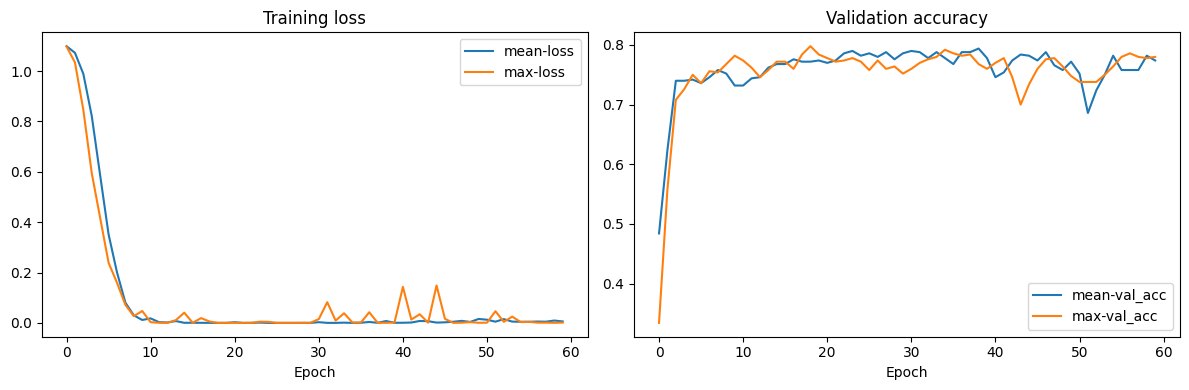

In [22]:
# Plot training curves
plot_training_curves(all_results)

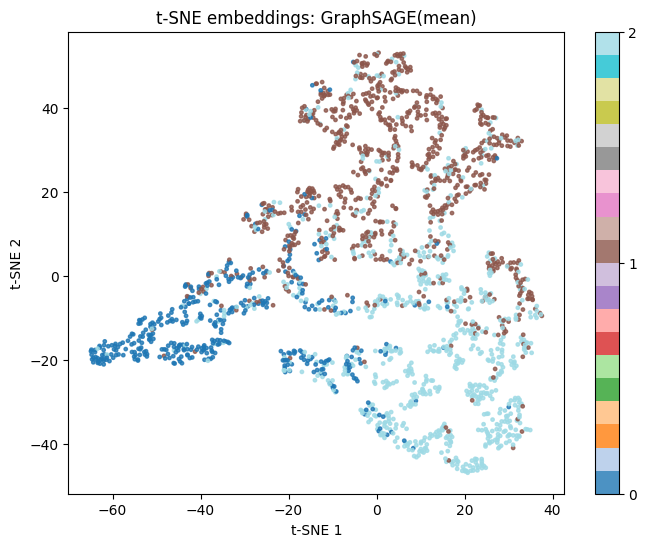

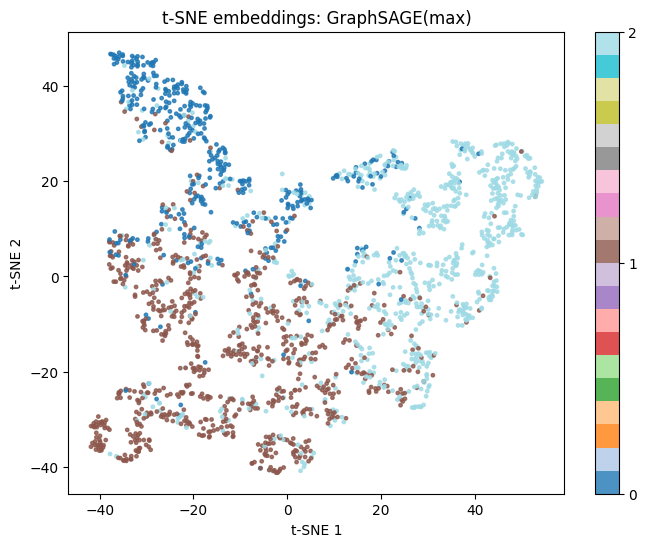

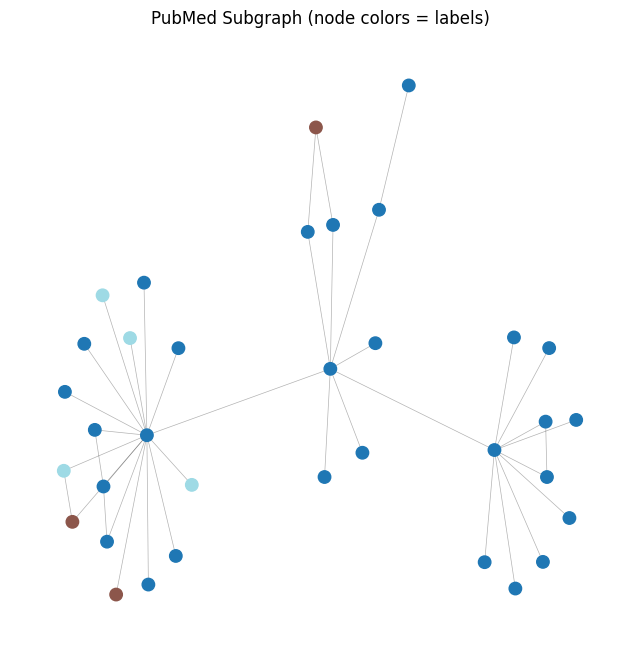

Outputs saved in graphsage_pubmed_outputs/


In [23]:
# t-SNE plots for each aggregator embeddings (labels = data.y numpy array)
labels_all = data.y.cpu().numpy()
for agg, r in all_results.items():
    tsne_plot(r['embeddings'], labels_all, title = f"t-SNE embeddings: GraphSAGE({agg})", sample_size = 2000)
    
# Small subgraph plot (using original graph and labels)
plot_small_subgraph(data, labels_all, sample_size = 300, title = "PubMed Subgraph (node colors = labels)")


# Save embeddings and predictions for later analysis
out_dir = "graphsage_pubmed_outputs"
os.makedirs(out_dir, exist_ok=True)
for agg, r in all_results.items():
    np.save(os.path.join(out_dir, f"embeddings_{agg}.npy"), r['embeddings'])
    np.save(os.path.join(out_dir, f"y_pred_test_{agg}.npy"), r['y_pred_test'])
    # Save training curves as well
    np.save(os.path.join(out_dir, f"train_losses_{agg}.npy"), np.array(r['train_losses']))
    np.save(os.path.join(out_dir, f"val_accs_{agg}.npy"), np.array(r['val_accs']))

print(f"Outputs saved in {out_dir}/")